<a href="https://colab.research.google.com/github/ehsankarami1358/LOKA_HYDRO/blob/main/Temperature_analyse_compare_2025_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

2025 rows: 2046
2026 rows: 655
   Year  count     MW_mean    MW_max  MVAr_mean   PF_mean       I_mean  \
0  2025   2046  111.629183  136.1738 -41.110808  0.930064  4853.666874   
1  2026    655  108.141784  136.3640 -19.514134  0.961862  4537.832980   

   I_imbalance_pct_mean  Winding_Temp_mean  Winding_Temp_max  TempSpread_mean  \
0              5.052740          41.530351          48.59999         0.158899   
1              5.242321          39.797092          52.24667         0.498728   

   TempSpread_max  TempRise_vs_CoolingWater_mean  \
0         1.46679                      28.455113   
1         5.77333                      28.905303   

   TempRise_vs_CoolingWater_max  TempRise_vs_ColdAir_mean  \
0                     34.496665                 22.594109   
1                     39.506665                 22.588610   

   TempRise_vs_ColdAir_max  I_per_MW_mean  FieldCurrent_per_MW_mean  
0                25.990010      43.555873                  6.638753  
1                30.6

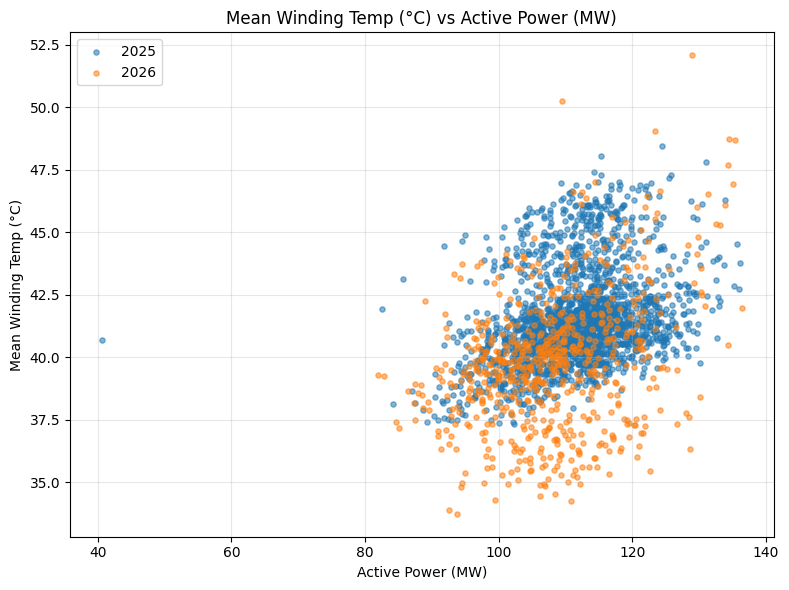

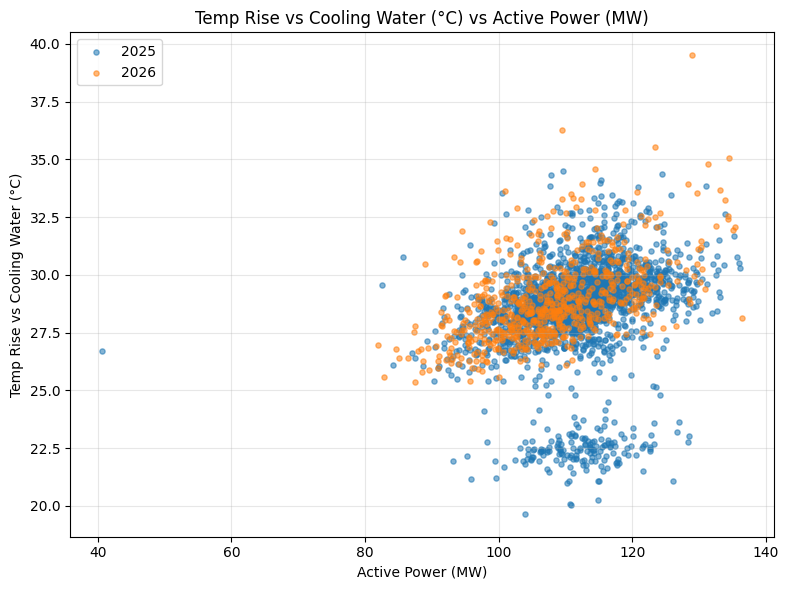

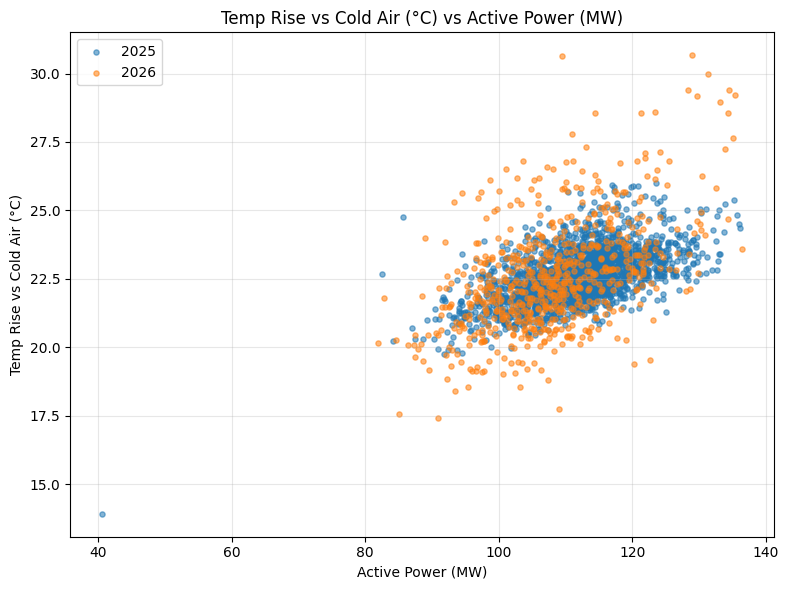

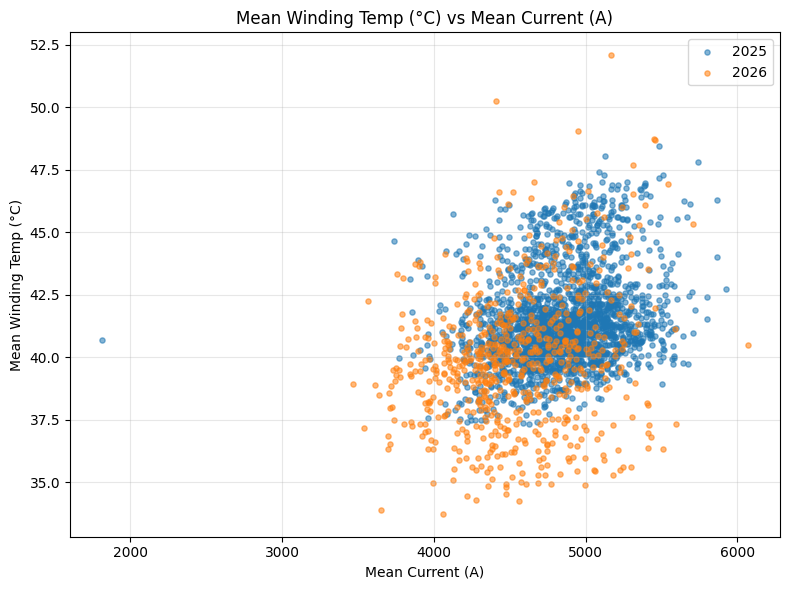

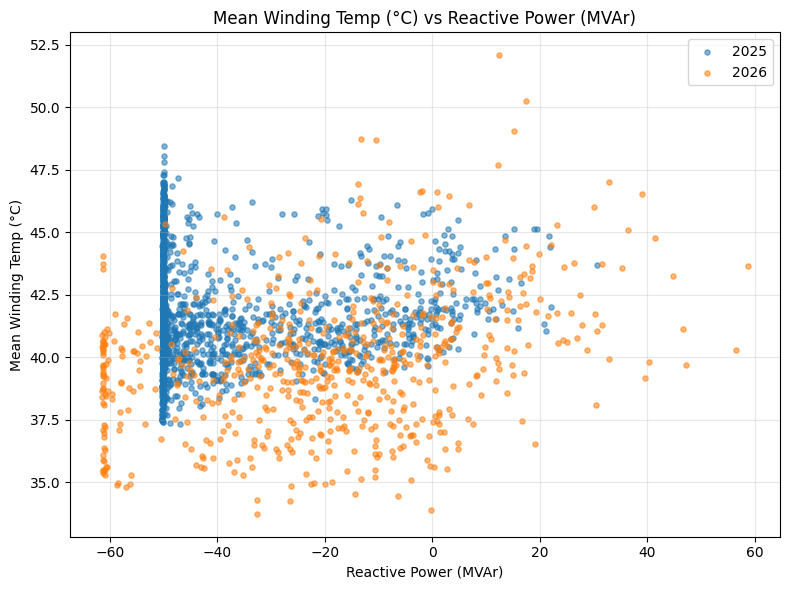

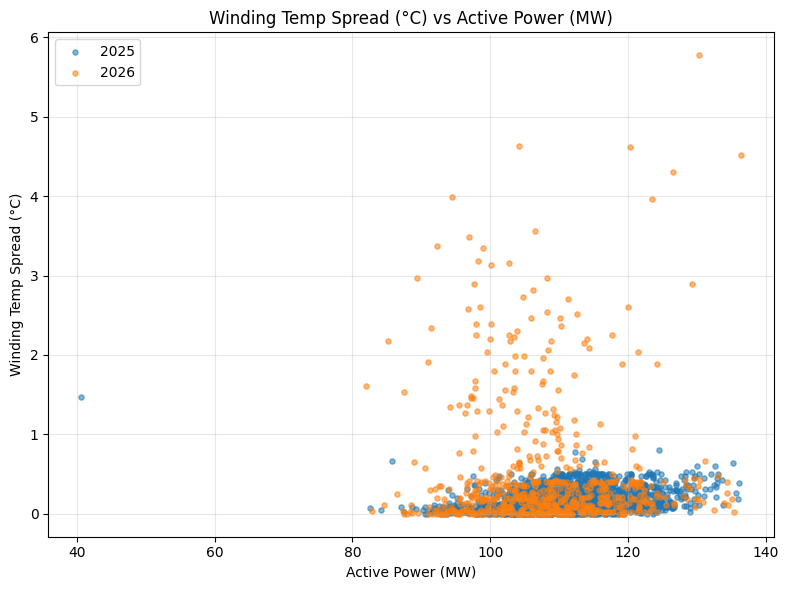

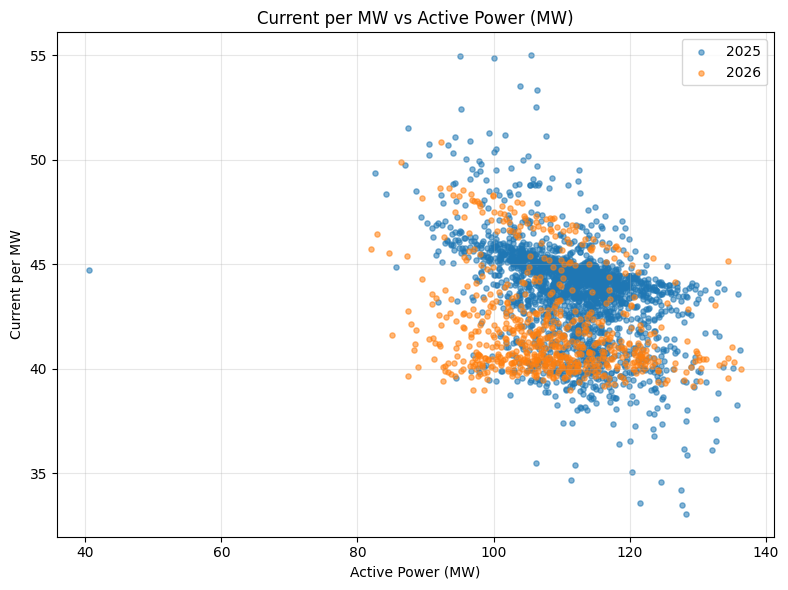

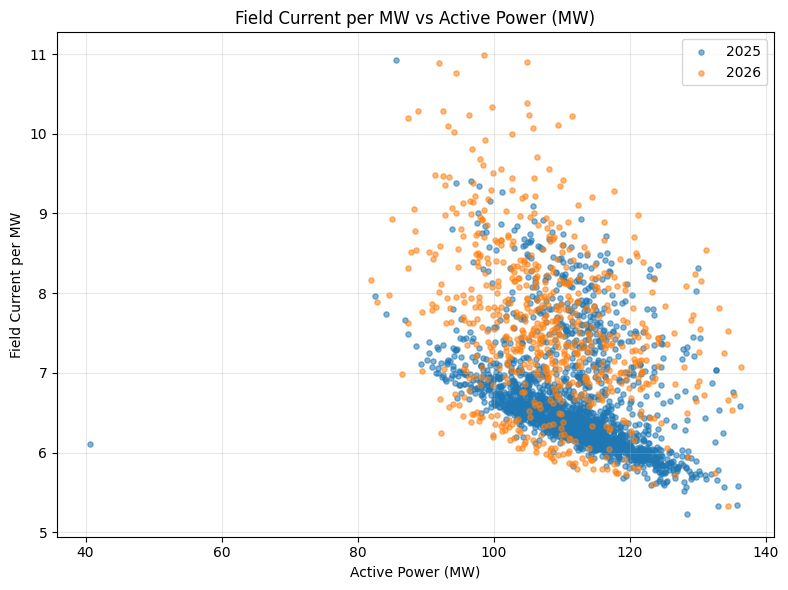

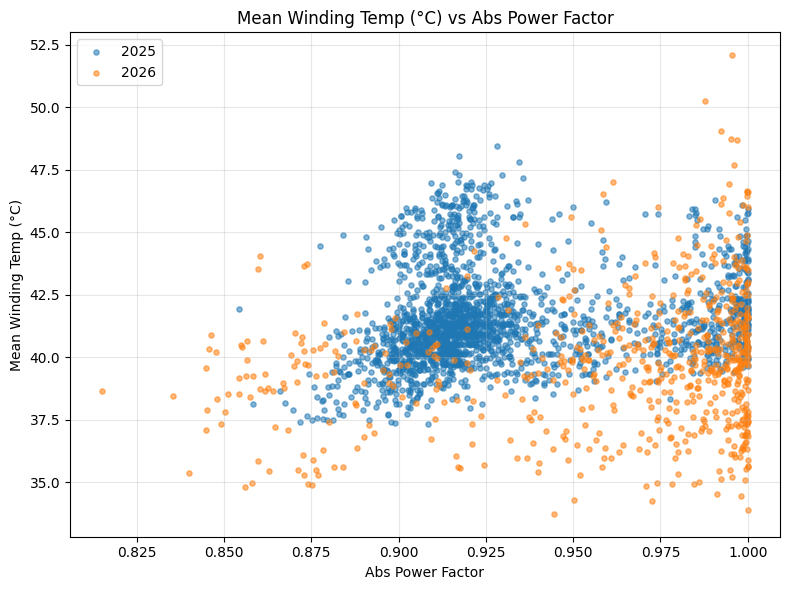

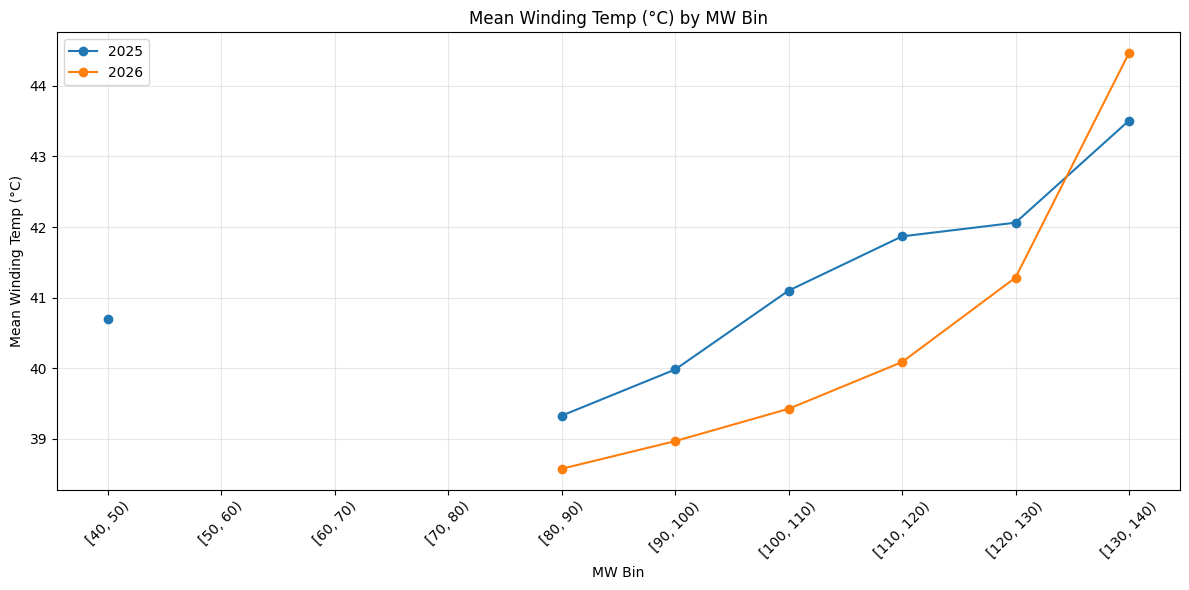

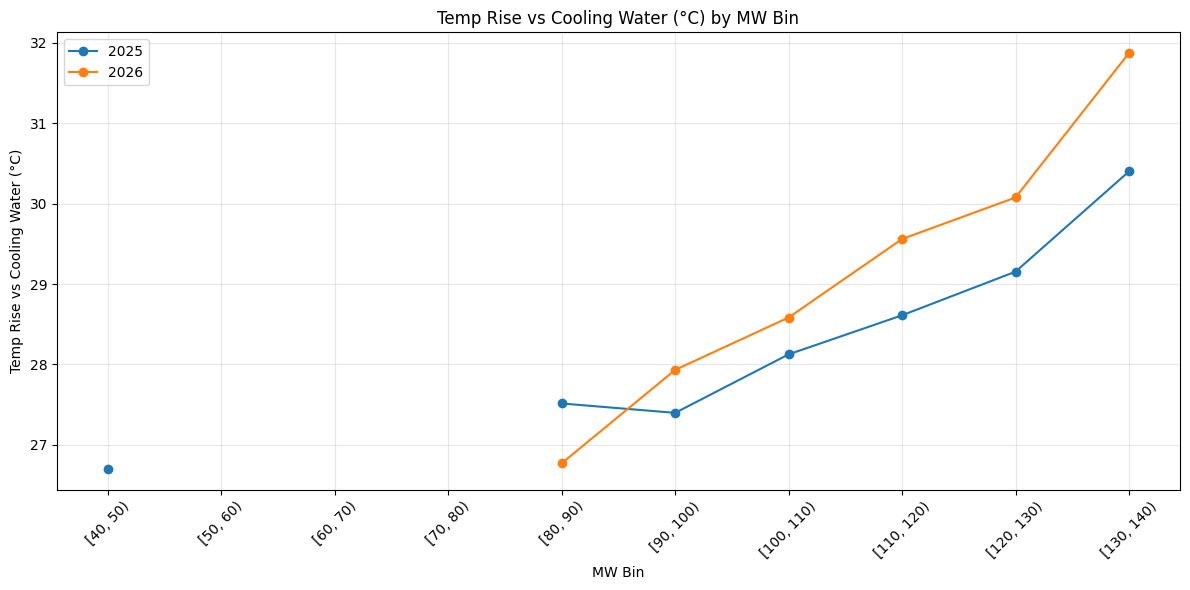

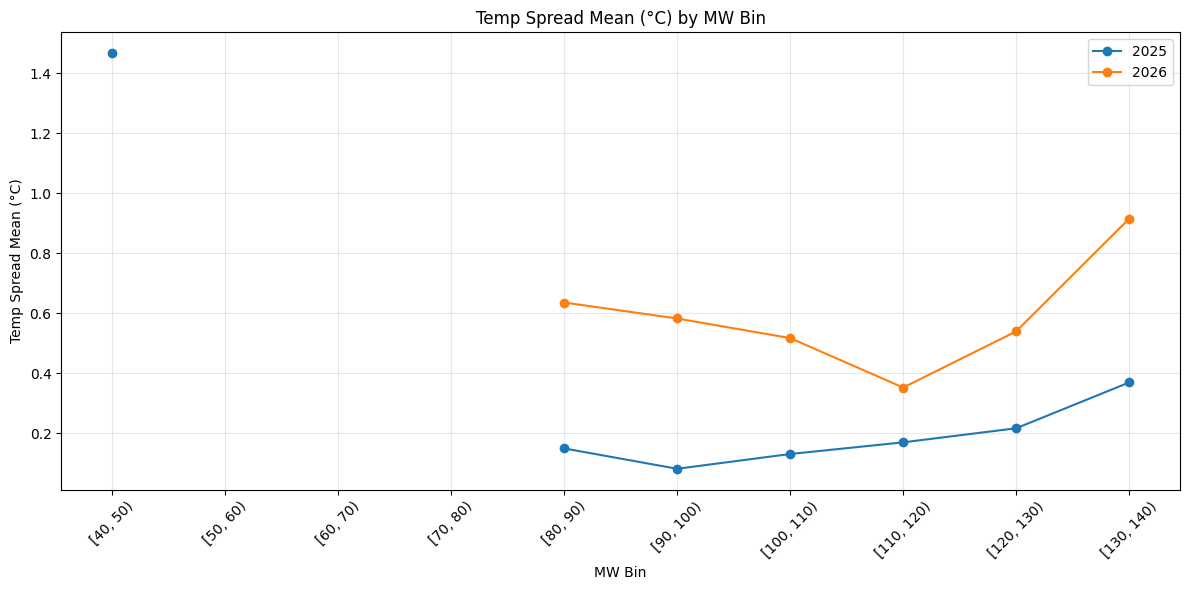

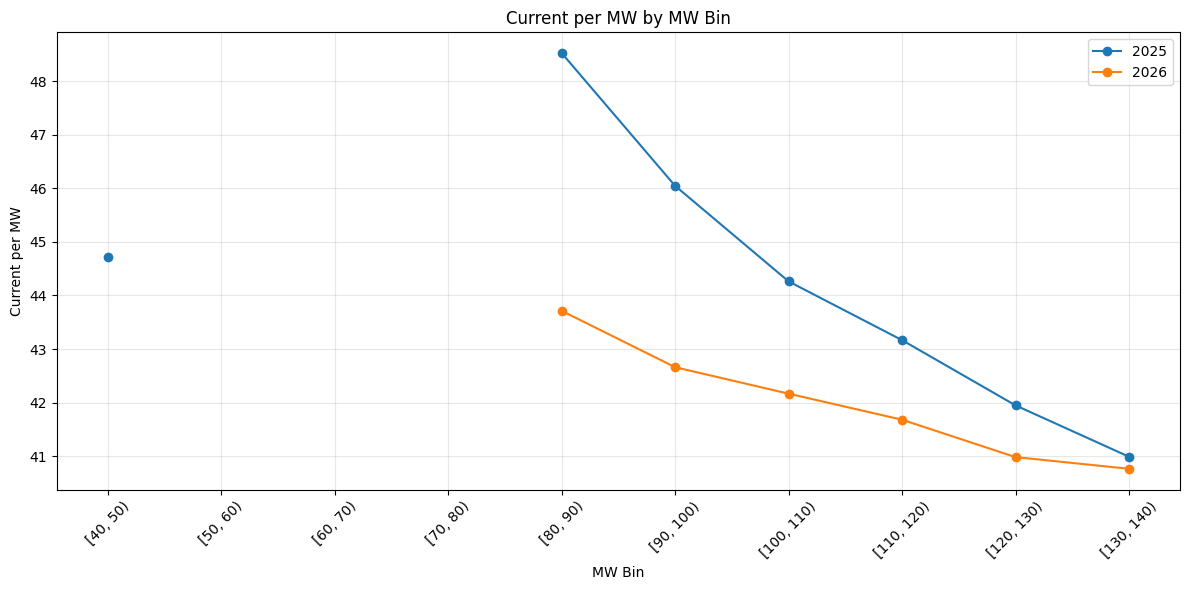

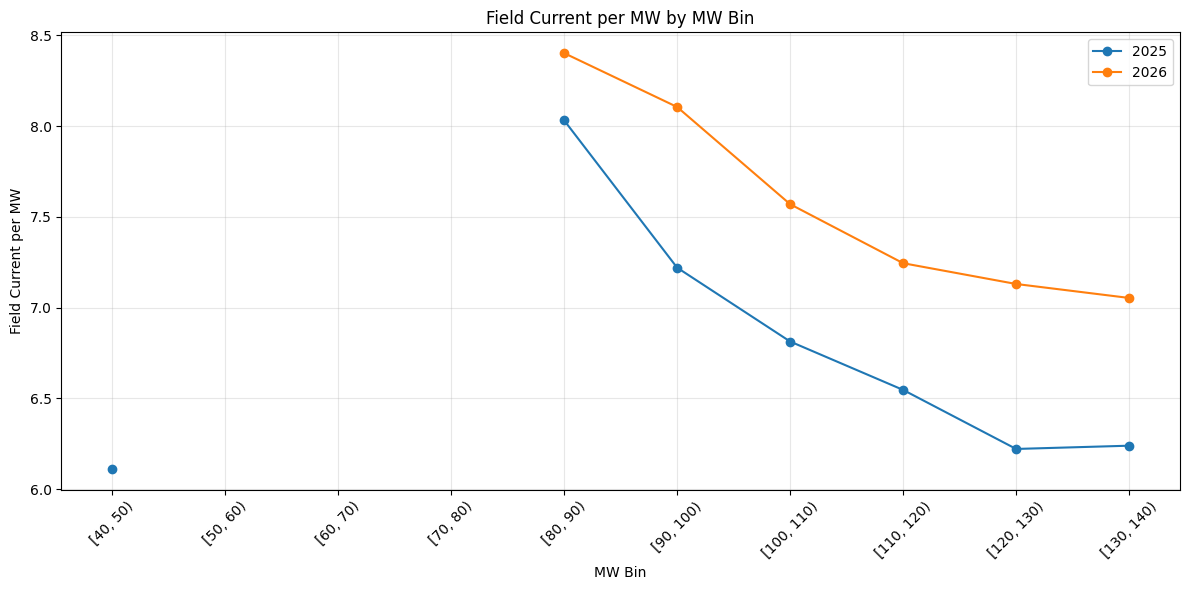

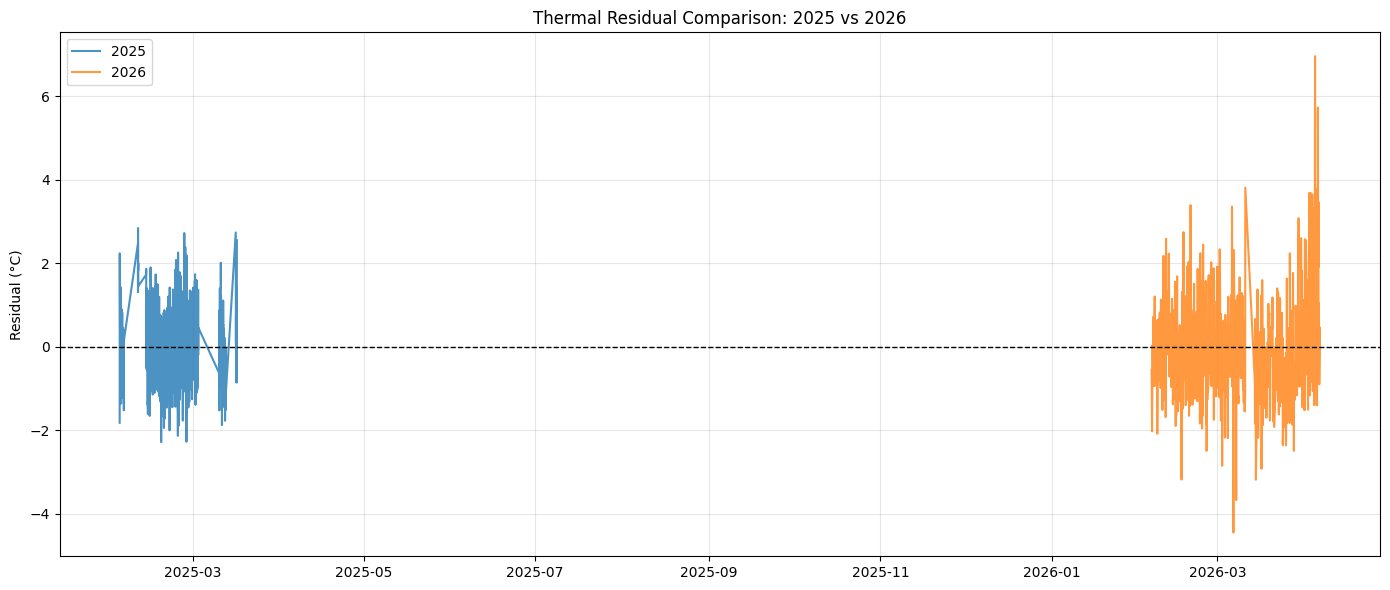


===== YEARLY SUMMARY =====
   Year  count     MW_mean    MW_max  MVAr_mean   PF_mean       I_mean  \
0  2025   2046  111.629183  136.1738 -41.110808  0.930064  4853.666874   
1  2026    655  108.141784  136.3640 -19.514134  0.961862  4537.832980   

   I_imbalance_pct_mean  Winding_Temp_mean  Winding_Temp_max  TempSpread_mean  \
0              5.052740          41.530351          48.59999         0.158899   
1              5.242321          39.797092          52.24667         0.498728   

   TempSpread_max  TempRise_vs_CoolingWater_mean  \
0         1.46679                      28.455113   
1         5.77333                      28.905303   

   TempRise_vs_CoolingWater_max  TempRise_vs_ColdAir_mean  \
0                     34.496665                 22.594109   
1                     39.506665                 22.588610   

   TempRise_vs_ColdAir_max  I_per_MW_mean  FieldCurrent_per_MW_mean  
0                25.990010      43.555873                  6.638753  
1                30.6666

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.linear_model import LinearRegression

# =========================================================
# 1. FILE PATHS
# =========================================================
files = {
    2025: {
        "electrical": r"u2_electrical_data_3_2_2025_17_3_2025_R1.csv",
        "temp": r"u2_winding_temp_3_2_2025_17_3_2025_R1.csv",
    },
    2026: {
        "electrical": r"u2_electrical_data_6_4_2026_R2.csv",
        "temp": r"u2_winding_temp_6_4_2026_R2.csv",
    }
}

output_dir = Path("generator_year_comparison_outputs")
output_dir.mkdir(exist_ok=True)

# =========================================================
# 2. ROBUST FILE READER
# 2025 files seem comma-separated utf-8
# 2026 files seem tab-separated utf-16
# This function handles both
# =========================================================
def robust_read_csv(file_path):
    attempts = [
        {"encoding": "utf-16", "sep": "\t"},
        {"encoding": "utf-8", "sep": ","},
        {"encoding": "utf-8-sig", "sep": ","},
        {"encoding": "utf-8", "sep": "\t"},
        {"encoding": "latin1", "sep": ","},
        {"encoding": "latin1", "sep": "\t"},
    ]

    last_error = None
    for cfg in attempts:
        try:
            df = pd.read_csv(file_path, encoding=cfg["encoding"], sep=cfg["sep"])
            if df.shape[1] > 1:
                df.columns = df.columns.str.strip()
                return df
        except Exception as e:
            last_error = e

    raise ValueError(f"Could not read file: {file_path}\nLast error: {last_error}")

# =========================================================
# 3. STANDARDIZE COLUMNS
# =========================================================
def standardize_columns(df):
    df.columns = df.columns.str.strip()

    rename_map = {
        "Active_power(MW)": "MW",
        "Reactive_power(Mvar)": "MVAr",
        "UNIT Voltage_AB(kV)": "V_AB_kV",
        "UNIT Voltage_BC(kV)": "V_BC_kV",
        "UNIT Voltage_CA(kV)": "V_CA_kV",
        "UNIT CURRENT PHASE A": "I_A",
        "UNIT CURRENT PHASE B": "I_B",
        "UNIT CURRENT PHASE C": "I_C",
        "FIELD CURRENT": "Field_Current",
        "FIELD VOLTAGE": "Field_Voltage",
        "FREQUENCY(Hz)": "Frequency_Hz",

        "STATOR WINDING PHASE U2 TEMP": "Winding_U2_Temp",
        "STATOR WINDING PHASE U164 TEMP": "Winding_U164_Temp",
        "COLD AIR TEMP": "Cold_Air_Temp",
        "HOT AIR TEMP": "Hot_Air_Temp",
        "UPPER GUIDE BEARING PAD TEMP": "UGB_Pad_Temp",
        "LOWER GUIDE BEARING PAD TEMP": "LGB_Pad_Temp",
        "UPPER BEARING OIL COOLER WARM WATER": "Upper_Bearing_Warm_Water",
        "LOWER BEARING OIL COOLER WARM WATER": "Lower_Bearing_Warm_Water",
        "GENERATOR COOLING WATER OUTLET TEMP": "Cooling_Water_Outlet_Temp",
        "GENERATOR COOLING WATER INLET TEMP": "Cooling_Water_Inlet_Temp",
    }

    df = df.rename(columns=rename_map)
    return df

# =========================================================
# 4. LOAD + PREPARE ONE YEAR
# =========================================================
def load_year_data(year, electrical_file, temp_file):
    elec = robust_read_csv(electrical_file)
    temp = robust_read_csv(temp_file)

    elec = standardize_columns(elec)
    temp = standardize_columns(temp)

    # timestamp
    elec["Timestamp"] = pd.to_datetime(elec["Timestamp"], errors="coerce")
    temp["Timestamp"] = pd.to_datetime(temp["Timestamp"], errors="coerce")

    elec = elec.dropna(subset=["Timestamp"]).sort_values("Timestamp").reset_index(drop=True)
    temp = temp.dropna(subset=["Timestamp"]).sort_values("Timestamp").reset_index(drop=True)

    # merge nearest
    df = pd.merge_asof(
        elec,
        temp,
        on="Timestamp",
        direction="nearest",
        tolerance=pd.Timedelta("10min")
    )

    # convert numeric
    for c in df.columns:
        if c != "Timestamp":
            df[c] = pd.to_numeric(df[c], errors="coerce")

    df["Year"] = year

    # required
    required = [
        "MW", "MVAr", "I_A", "I_B", "I_C",
        "Winding_U2_Temp", "Winding_U164_Temp"
    ]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"{year} missing required columns: {missing}")

    # derived values
    if {"V_AB_kV", "V_BC_kV", "V_CA_kV"}.issubset(df.columns):
        df["V_mean_kV"] = df[["V_AB_kV", "V_BC_kV", "V_CA_kV"]].mean(axis=1)
    else:
        df["V_mean_kV"] = np.nan

    df["I_mean"] = df[["I_A", "I_B", "I_C"]].mean(axis=1)
    df["I_max"] = df[["I_A", "I_B", "I_C"]].max(axis=1)
    df["I_min"] = df[["I_A", "I_B", "I_C"]].min(axis=1)
    df["I_imbalance_pct"] = np.where(
        df["I_mean"] != 0,
        (df["I_max"] - df["I_min"]) / df["I_mean"] * 100,
        np.nan
    )

    df["Winding_Temp_mean"] = df[["Winding_U2_Temp", "Winding_U164_Temp"]].mean(axis=1)
    df["Winding_Temp_max"] = df[["Winding_U2_Temp", "Winding_U164_Temp"]].max(axis=1)
    df["Winding_Temp_min"] = df[["Winding_U2_Temp", "Winding_U164_Temp"]].min(axis=1)
    df["Winding_Temp_spread"] = df["Winding_Temp_max"] - df["Winding_Temp_min"]

    if "Cooling_Water_Inlet_Temp" in df.columns:
        df["TempRise_vs_CoolingWater"] = df["Winding_Temp_mean"] - df["Cooling_Water_Inlet_Temp"]
    else:
        df["TempRise_vs_CoolingWater"] = np.nan

    if "Cold_Air_Temp" in df.columns:
        df["TempRise_vs_ColdAir"] = df["Winding_Temp_mean"] - df["Cold_Air_Temp"]
    else:
        df["TempRise_vs_ColdAir"] = np.nan

    df["MVA"] = np.sqrt(df["MW"]**2 + df["MVAr"]**2)
    df["PF_abs"] = np.where(df["MVA"] != 0, np.abs(df["MW"]) / df["MVA"], np.nan)

    df["I_per_MW"] = np.where(df["MW"] != 0, df["I_mean"] / df["MW"], np.nan)

    if "Field_Current" in df.columns:
        df["FieldCurrent_per_MW"] = np.where(df["MW"] != 0, df["Field_Current"] / df["MW"], np.nan)
    else:
        df["FieldCurrent_per_MW"] = np.nan

    # basic operation filter
    df["MW_diff_abs"] = df["MW"].diff().abs()
    df = df[
        (df["MW"] > 20) &
        (df["MW_diff_abs"].fillna(0) < 15)
    ].copy()

    return df

# =========================================================
# 5. LOAD BOTH YEARS
# =========================================================
df_2025 = load_year_data(2025, files[2025]["electrical"], files[2025]["temp"])
df_2026 = load_year_data(2026, files[2026]["electrical"], files[2026]["temp"])

df_all = pd.concat([df_2025, df_2026], ignore_index=True)

print("2025 rows:", len(df_2025))
print("2026 rows:", len(df_2026))

# save merged yearly datasets
df_2025.to_csv(output_dir / "merged_2025.csv", index=False)
df_2026.to_csv(output_dir / "merged_2026.csv", index=False)
df_all.to_csv(output_dir / "merged_all_years.csv", index=False)

# =========================================================
# 6. QUICK SUMMARY TABLE
# =========================================================
summary = df_all.groupby("Year").agg(
    count=("MW", "size"),
    MW_mean=("MW", "mean"),
    MW_max=("MW", "max"),
    MVAr_mean=("MVAr", "mean"),
    PF_mean=("PF_abs", "mean"),
    I_mean=("I_mean", "mean"),
    I_imbalance_pct_mean=("I_imbalance_pct", "mean"),
    Winding_Temp_mean=("Winding_Temp_mean", "mean"),
    Winding_Temp_max=("Winding_Temp_max", "max"),
    TempSpread_mean=("Winding_Temp_spread", "mean"),
    TempSpread_max=("Winding_Temp_spread", "max"),
    TempRise_vs_CoolingWater_mean=("TempRise_vs_CoolingWater", "mean"),
    TempRise_vs_CoolingWater_max=("TempRise_vs_CoolingWater", "max"),
    TempRise_vs_ColdAir_mean=("TempRise_vs_ColdAir", "mean"),
    TempRise_vs_ColdAir_max=("TempRise_vs_ColdAir", "max"),
    I_per_MW_mean=("I_per_MW", "mean"),
    FieldCurrent_per_MW_mean=("FieldCurrent_per_MW", "mean"),
).reset_index()

summary.to_csv(output_dir / "yearly_summary.csv", index=False)
print(summary)

# =========================================================
# 7. MW-BIN COMPARISON
# =========================================================
mw_bins = np.arange(20, 151, 10)
df_all["MW_bin"] = pd.cut(df_all["MW"], bins=mw_bins, right=False)

mw_bin_summary = df_all.groupby(["Year", "MW_bin"], observed=False).agg(
    count=("MW", "size"),
    MW_mean=("MW", "mean"),
    MVAr_mean=("MVAr", "mean"),
    PF_mean=("PF_abs", "mean"),
    I_mean=("I_mean", "mean"),
    Winding_Temp_mean=("Winding_Temp_mean", "mean"),
    Winding_Temp_max=("Winding_Temp_mean", "max"),
    TempSpread_mean=("Winding_Temp_spread", "mean"),
    TempSpread_max=("Winding_Temp_spread", "max"),
    TempRise_CW_mean=("TempRise_vs_CoolingWater", "mean"),
    TempRise_CA_mean=("TempRise_vs_ColdAir", "mean"),
    I_per_MW_mean=("I_per_MW", "mean"),
    FieldCurrent_per_MW_mean=("FieldCurrent_per_MW", "mean"),
).reset_index()

mw_bin_summary.to_csv(output_dir / "mw_bin_summary_by_year.csv", index=False)

# wide comparison 2025 vs 2026
pivot_temp = mw_bin_summary.pivot(index="MW_bin", columns="Year", values="Winding_Temp_mean")
pivot_rise_cw = mw_bin_summary.pivot(index="MW_bin", columns="Year", values="TempRise_CW_mean")
pivot_spread = mw_bin_summary.pivot(index="MW_bin", columns="Year", values="TempSpread_mean")
pivot_i_per_mw = mw_bin_summary.pivot(index="MW_bin", columns="Year", values="I_per_MW_mean")

comparison_bins = pd.DataFrame(index=pivot_temp.index)
comparison_bins["WindingTemp_2025"] = pivot_temp.get(2025)
comparison_bins["WindingTemp_2026"] = pivot_temp.get(2026)
comparison_bins["delta_WindingTemp_2026_minus_2025"] = comparison_bins["WindingTemp_2026"] - comparison_bins["WindingTemp_2025"]

comparison_bins["TempRiseCW_2025"] = pivot_rise_cw.get(2025)
comparison_bins["TempRiseCW_2026"] = pivot_rise_cw.get(2026)
comparison_bins["delta_TempRiseCW_2026_minus_2025"] = comparison_bins["TempRiseCW_2026"] - comparison_bins["TempRiseCW_2025"]

comparison_bins["TempSpread_2025"] = pivot_spread.get(2025)
comparison_bins["TempSpread_2026"] = pivot_spread.get(2026)
comparison_bins["delta_TempSpread_2026_minus_2025"] = comparison_bins["TempSpread_2026"] - comparison_bins["TempSpread_2025"]

comparison_bins["I_per_MW_2025"] = pivot_i_per_mw.get(2025)
comparison_bins["I_per_MW_2026"] = pivot_i_per_mw.get(2026)
comparison_bins["delta_I_per_MW_2026_minus_2025"] = comparison_bins["I_per_MW_2026"] - comparison_bins["I_per_MW_2025"]

comparison_bins.reset_index().to_csv(output_dir / "mw_bin_comparison_2025_vs_2026.csv", index=False)

# =========================================================
# 8. PLOTS - SCATTER COMPARISON
# =========================================================
def scatter_compare(xcol, ycol, xlabel, ylabel, filename):
    plt.figure(figsize=(8, 6))
    for year, df in [(2025, df_2025), (2026, df_2026)]:
        plt.scatter(df[xcol], df[ycol], s=14, alpha=0.55, label=str(year))
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(f"{ylabel} vs {xlabel}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(output_dir / filename, dpi=200)
    plt.show()

scatter_compare("MW", "Winding_Temp_mean", "Active Power (MW)", "Mean Winding Temp (°C)", "01_compare_temp_vs_MW.png")
scatter_compare("MW", "TempRise_vs_CoolingWater", "Active Power (MW)", "Temp Rise vs Cooling Water (°C)", "02_compare_tempRiseCW_vs_MW.png")
scatter_compare("MW", "TempRise_vs_ColdAir", "Active Power (MW)", "Temp Rise vs Cold Air (°C)", "03_compare_tempRiseCA_vs_MW.png")
scatter_compare("I_mean", "Winding_Temp_mean", "Mean Current (A)", "Mean Winding Temp (°C)", "04_compare_temp_vs_current.png")
scatter_compare("MVAr", "Winding_Temp_mean", "Reactive Power (MVAr)", "Mean Winding Temp (°C)", "05_compare_temp_vs_MVAr.png")
scatter_compare("MW", "Winding_Temp_spread", "Active Power (MW)", "Winding Temp Spread (°C)", "06_compare_spread_vs_MW.png")
scatter_compare("MW", "I_per_MW", "Active Power (MW)", "Current per MW", "07_compare_IperMW_vs_MW.png")
scatter_compare("MW", "FieldCurrent_per_MW", "Active Power (MW)", "Field Current per MW", "08_compare_FieldCurrentPerMW_vs_MW.png")
scatter_compare("PF_abs", "Winding_Temp_mean", "Abs Power Factor", "Mean Winding Temp (°C)", "09_compare_temp_vs_PF.png")

# =========================================================
# 9. MW-BIN LINE COMPARISON
# =========================================================
def line_bin_compare(value_col, ylabel, filename):
    temp_plot = mw_bin_summary.copy()
    temp_plot["MW_bin_str"] = temp_plot["MW_bin"].astype(str)

    plt.figure(figsize=(12, 6))
    for year in [2025, 2026]:
        sub = temp_plot[temp_plot["Year"] == year]
        plt.plot(sub["MW_bin_str"], sub[value_col], marker="o", label=str(year))
    plt.xticks(rotation=45)
    plt.ylabel(ylabel)
    plt.xlabel("MW Bin")
    plt.title(f"{ylabel} by MW Bin")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(output_dir / filename, dpi=200)
    plt.show()

line_bin_compare("Winding_Temp_mean", "Mean Winding Temp (°C)", "10_bin_compare_temp.png")
line_bin_compare("TempRise_CW_mean", "Temp Rise vs Cooling Water (°C)", "11_bin_compare_tempRiseCW.png")
line_bin_compare("TempSpread_mean", "Temp Spread Mean (°C)", "12_bin_compare_spread.png")
line_bin_compare("I_per_MW_mean", "Current per MW", "13_bin_compare_IperMW.png")
line_bin_compare("FieldCurrent_per_MW_mean", "Field Current per MW", "14_bin_compare_FieldCurrentPerMW.png")

# =========================================================
# 10. TIME TREND OF EACH YEAR
# =========================================================
def time_trend_plot(df, year, filename):
    fig, ax1 = plt.subplots(figsize=(14, 6))
    ax1.plot(df["Timestamp"], df["MW"], label="MW")
    ax1.set_ylabel("MW")
    ax1.set_title(f"{year} - MW and Mean Winding Temp")

    ax2 = ax1.twinx()
    ax2.plot(df["Timestamp"], df["Winding_Temp_mean"], label="Winding Temp Mean", alpha=0.8)
    ax2.set_ylabel("Winding Temp (°C)")

    fig.tight_layout()
    plt.savefig(output_dir / filename, dpi=200)
    plt.close()

time_trend_plot(df_2025, 2025, "15_time_trend_2025.png")
time_trend_plot(df_2026, 2026, "16_time_trend_2026.png")

# =========================================================
# 11. TEMPERATURE MODEL FOR EACH YEAR
# Compare residual behavior
# =========================================================
def fit_temp_model(df, year):
    features = ["MW", "MVAr", "I_mean", "V_mean_kV", "PF_abs"]
    if "Cooling_Water_Inlet_Temp" in df.columns:
        features.append("Cooling_Water_Inlet_Temp")
    if "Cold_Air_Temp" in df.columns:
        features.append("Cold_Air_Temp")
    if "Field_Current" in df.columns:
        features.append("Field_Current")

    features = [c for c in features if c in df.columns]

    model_df = df.dropna(subset=features + ["Winding_Temp_mean"]).copy()
    X = model_df[features]
    y = model_df["Winding_Temp_mean"]

    model = LinearRegression()
    model.fit(X, y)

    model_df["Temp_pred"] = model.predict(X)
    model_df["Temp_residual"] = model_df["Winding_Temp_mean"] - model_df["Temp_pred"]
    model_df["Year"] = year

    coef_df = pd.DataFrame({
        "Feature": features,
        "Coefficient": model.coef_,
        "Year": year
    })

    return model_df, coef_df

model_2025, coef_2025 = fit_temp_model(df_2025, 2025)
model_2026, coef_2026 = fit_temp_model(df_2026, 2026)

model_all = pd.concat([model_2025, model_2026], ignore_index=True)
coef_all = pd.concat([coef_2025, coef_2026], ignore_index=True)

model_all.to_csv(output_dir / "temperature_model_residuals_by_year.csv", index=False)
coef_all.to_csv(output_dir / "temperature_model_coefficients_by_year.csv", index=False)

res_summary = model_all.groupby("Year").agg(
    Residual_mean=("Temp_residual", "mean"),
    Residual_std=("Temp_residual", "std"),
    Residual_abs_mean=("Temp_residual", lambda s: np.mean(np.abs(s))),
    Residual_max=("Temp_residual", "max"),
    Residual_min=("Temp_residual", "min"),
).reset_index()

res_summary.to_csv(output_dir / "residual_summary_by_year.csv", index=False)

plt.figure(figsize=(14, 6))
for year, dfm in [(2025, model_2025), (2026, model_2026)]:
    plt.plot(dfm["Timestamp"], dfm["Temp_residual"], label=str(year), alpha=0.8)
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.ylabel("Residual (°C)")
plt.title("Thermal Residual Comparison: 2025 vs 2026")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(output_dir / "17_residual_comparison.png", dpi=200)
plt.show()

# =========================================================
# 12. HOTSPOT / SPREAD / FLAG COMPARISON
# =========================================================
df_all["High_Spread_Flag"] = df_all["Winding_Temp_spread"] > 2.0
df_all["High_TempRiseCW_Flag"] = df_all["TempRise_vs_CoolingWater"] > df_all["TempRise_vs_CoolingWater"].quantile(0.95)
df_all["High_Iimbalance_Flag"] = df_all["I_imbalance_pct"] > 5.0
df_all["Low_PF_Flag"] = df_all["PF_abs"] < 0.90

flags_summary = df_all.groupby("Year").agg(
    rows=("MW", "size"),
    High_Spread_count=("High_Spread_Flag", "sum"),
    High_TempRiseCW_count=("High_TempRiseCW_Flag", "sum"),
    High_Iimbalance_count=("High_Iimbalance_Flag", "sum"),
    Low_PF_count=("Low_PF_Flag", "sum"),
).reset_index()

flags_summary["High_Spread_pct"] = flags_summary["High_Spread_count"] / flags_summary["rows"] * 100
flags_summary["High_TempRiseCW_pct"] = flags_summary["High_TempRiseCW_count"] / flags_summary["rows"] * 100
flags_summary["High_Iimbalance_pct"] = flags_summary["High_Iimbalance_count"] / flags_summary["rows"] * 100
flags_summary["Low_PF_pct"] = flags_summary["Low_PF_count"] / flags_summary["rows"] * 100

flags_summary.to_csv(output_dir / "flags_summary_2025_vs_2026.csv", index=False)

# =========================================================
# 13. FINAL PRINTS
# =========================================================
print("\n===== YEARLY SUMMARY =====")
print(summary)

print("\n===== RESIDUAL SUMMARY =====")
print(res_summary)

print("\n===== FLAGS SUMMARY =====")
print(flags_summary)

print("\nAll results saved in:")
print(output_dir.resolve())